In [1]:
#pip install xarray

In [2]:
#pip install matplotlib

In [3]:
#pip install netCDF4

In [4]:
#pip install scipy

In [5]:
#pip install geopy

In [1]:
import xarray as xr
import pandas as pd
import os
import time
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec


# serial code start here

## load data serially

In [2]:
years = range(2012, 2022)


In [3]:
for year in years:
    file_path = f"./All Data 2012 - 2021/CHIRPS_total_precipitation_day_0.25x0.25_africa_{year}_v2.0.nc"
    ds = xr.open_dataset(file_path)
    print(year, list(ds.coords), list(ds.data_vars))
    ds.close()

2012 ['time', 'lon', 'lat'] ['pr']
2013 ['time', 'lon', 'lat'] ['pr']
2014 ['time', 'lon', 'lat'] ['pr']
2015 ['time', 'lon', 'lat'] ['pr']
2016 ['time', 'lon', 'lat'] ['pr']
2017 ['time', 'lon', 'lat'] ['pr']
2018 ['time', 'lon', 'lat'] ['pr']
2019 ['time', 'lon', 'lat'] ['pr']
2020 ['time', 'lon', 'lat'] ['pr']
2021 ['time', 'longitude', 'latitude'] ['pr']


In [ ]:
#data from 2021 use 'longitude', 'latitude' while data from the other years use 'lon', 'lat'

In [4]:
data_list = []
t0 = time.perf_counter()
for year in years:
    print(f"Started processing file: CHIRPS_total_precipitation_day_0.25x0.25_africa_{year}_v2.0.nc")
    file_path = f"./All Data 2012 - 2021/CHIRPS_total_precipitation_day_0.25x0.25_africa_{year}_v2.0.nc"
    
    ds = xr.open_dataset(file_path)
    
    # Normalize coordinate names to lat/lon
    rename_map = {}
    if 'latitude' in ds.coords: rename_map['latitude'] = 'lat'
    if 'longitude' in ds.coords: rename_map['longitude'] = 'lon'
    if rename_map:
        ds = ds.rename(rename_map)
    
    df = ds.to_dataframe().dropna().reset_index()
    
    # Add year column
    df['time'] = pd.to_datetime(df['time'])
    df['year'] = df['time'].dt.year
    
    data_list.append(df)  # ← removed .sample(), append full DataFrame
    
    ds.close()
    print(f"finished processing file: CHIRPS_total_precipitation_day_0.25x0.25_africa_{year}_v2.0.nc")

data= pd.concat(data_list, ignore_index=True)
print(f"Time taken by serial code data loading: {time.perf_counter() - t0:.2f} seconds")


Started processing file: CHIRPS_total_precipitation_day_0.25x0.25_africa_2012_v2.0.nc
finished processing file: CHIRPS_total_precipitation_day_0.25x0.25_africa_2012_v2.0.nc
Started processing file: CHIRPS_total_precipitation_day_0.25x0.25_africa_2013_v2.0.nc
finished processing file: CHIRPS_total_precipitation_day_0.25x0.25_africa_2013_v2.0.nc
Started processing file: CHIRPS_total_precipitation_day_0.25x0.25_africa_2014_v2.0.nc
finished processing file: CHIRPS_total_precipitation_day_0.25x0.25_africa_2014_v2.0.nc
Started processing file: CHIRPS_total_precipitation_day_0.25x0.25_africa_2015_v2.0.nc
finished processing file: CHIRPS_total_precipitation_day_0.25x0.25_africa_2015_v2.0.nc
Started processing file: CHIRPS_total_precipitation_day_0.25x0.25_africa_2016_v2.0.nc
finished processing file: CHIRPS_total_precipitation_day_0.25x0.25_africa_2016_v2.0.nc
Started processing file: CHIRPS_total_precipitation_day_0.25x0.25_africa_2017_v2.0.nc
finished processing file: CHIRPS_total_precipitat

In [5]:
print(len(data))

191340011


In [6]:
data.head()

,time,lat,lon,pr,year
0,2012-01-01 12:00:00,-34.875,19.875,0.0,2012
1,2012-01-01 12:00:00,-34.625,19.375,0.0,2012
2,2012-01-01 12:00:00,-34.625,19.625,0.0,2012
3,2012-01-01 12:00:00,-34.625,19.875,0.0,2012
4,2012-01-01 12:00:00,-34.625,20.125,0.0,2012


In [7]:
data.tail()

,time,lat,lon,pr,year
191340006,2021-08-31,49.875,143.125,3.473567,2021
191340007,2021-08-31,49.875,143.375,1.356130,2021
191340008,2021-08-31,49.875,143.625,0.326433,2021
191340009,2021-08-31,49.875,143.875,2.136942,2021
191340010,2021-08-31,49.875,144.125,6.475855,2021


## use names to display data

## Statistic computation

In [12]:
agregation_per_location  = data.groupby(['lat', 'lon'])['pr'].agg(
    avg_precipitation  ='mean',
    max_precipitation  ='max'
).reset_index()
agregation_per_location = agregation_per_location.round(3)

print(agregation_per_location.head())

      lat     lon  avg_precipitation  max_precipitation
0 -49.875 -75.375              7.505         100.190002
1 -49.875 -75.125              5.989          84.349998
2 -49.875 -74.875              4.254          95.897003
3 -49.875 -74.625              2.757          34.778000
4 -49.875 -74.375              2.285          32.830002


In [13]:
yearly_stats = data.groupby('year')['pr'].agg(
    avg_pr='mean',
    max_pr='max'
).reset_index()

# Linear regression on yearly average
slope, intercept, r, p, se = stats.linregress(yearly_stats['year'], yearly_stats['avg_pr'])
yearly_stats['trend'] = intercept + slope * yearly_stats['year']

print(yearly_stats)
print(f"Slope: {slope:.4f} mm/year | R²: {r**2:.4f} | p-value: {p:.4f}")

   year    avg_pr       max_pr     trend
0  2012  1.658738   366.000000  1.464095
1  2013  1.594302   476.000000  1.519638
2  2014  1.592540   453.000000  1.575180
3  2015  1.511377   295.000000  1.630722
4  2016  1.575540   321.000000  1.686265
5  2017  1.632312   550.000000  1.741807
6  2018  1.732177   367.000000  1.797349
7  2019  1.725150   590.000000  1.852892
8  2020  1.596485   288.000000  1.908434
9  2021  2.521736  1126.449707  1.963976
Slope: 0.0555 mm/year | R²: 0.3324 | p-value: 0.0811


In [14]:
threshold_95 = data['pr'].quantile(0.95)
extreme_events = data[data['pr'] > threshold_95]

print(f"95th percentile threshold : {threshold_95:.4f} mm")
print(f"Total extreme events      : {len(extreme_events):,}")
print(f"% of total records        : {100 * len(extreme_events) / len(data):.2f}%")

# Extreme events per year
extreme_per_year = extreme_events.groupby('year').size().reset_index(name='extreme_count')
print(extreme_per_year)

95th percentile threshold : 12.0000 mm
Total extreme events      : 8,752,315
% of total records        : 4.57%
   year  extreme_count
0  2012         745711
1  2013         695580
2  2014         685142
3  2015         656746
4  2016         702002
5  2017         729956
6  2018         758645
7  2019         752041
8  2020         343075
9  2021        2683417


In [ ]:


    # ──────────────────────────────────────────────
    # PLOTTING
    # ──────────────────────────────────────────────

        
    # ==============================
    # Plot 1: Spatial avg precipitation
    # ==============================
    fig, ax = plt.subplots(figsize=(7, 5))
    sc = ax.scatter(
        spatial_agg['lon'], spatial_agg['lat'],
        c=spatial_agg['avg_precipitation'],
        cmap='YlOrRd', s=2, alpha=0.6
    )
    plt.colorbar(sc, ax=ax, label='mm')
    ax.set_title('Average Precipitation per (Lat, Lon)')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    plt.savefig(os.path.join(output_dir, 'plot1_avg_precipitation.png'),
                dpi=400, bbox_inches='tight')
    plt.close()

    # ==============================
    # Plot 2: Spatial max precipitation
    # ==============================
    fig, ax = plt.subplots(figsize=(7, 5))
    sc = ax.scatter(
        spatial_agg['lon'], spatial_agg['lat'],
        c=spatial_agg['max_precipitation'],
        cmap='Blues', s=2, alpha=0.6
    )
    plt.colorbar(sc, ax=ax, label='mm')
    ax.set_title('Maximum Precipitation per (Lat, Lon)')
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    plt.savefig(os.path.join(output_dir, 'plot2_max_precipitation.png'),
                dpi=400, bbox_inches='tight')
    plt.close()

    # ==============================
    # Plot 3: Yearly average trend
    # ==============================
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(
        yearly_agg['year'],
        yearly_agg['avg_precipitation'],
        marker='o',
        color='steelblue',
        label='Yearly Avg'
    )
    reg_line = slope_avg * yearly_agg['year'] + intercept_avg
    ax.plot(
        yearly_agg['year'],
        reg_line,
        linestyle='--',
        color='red',
        label=f'Trend (slope={slope_avg:.4f}, R²={r_avg**2:.3f})'
    )
    ax.set_title('Yearly Average Precipitation')
    ax.set_xlabel('Year')
    ax.set_ylabel('Avg Precipitation (mm)')
    ax.legend()
    plt.savefig(os.path.join(output_dir, 'plot3_yearly_avg_trend.png'),
                dpi=400, bbox_inches='tight')
    plt.close()

    # ==============================
    # Plot 4: Yearly max trend
    # ==============================
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(
        yearly_agg['year'],
        yearly_agg['max_precipitation'],
        marker='s',
        color='darkorange',
        label='Yearly Max'
    )
    reg_line = slope_max * yearly_agg['year'] + intercept_max
    ax.plot(
        yearly_agg['year'],
        reg_line,
        linestyle='--',
        color='red',
        label=f'Trend (slope={slope_max:.2f}, R²={r_max**2:.3f})'
    )
    ax.set_title('Yearly Maximum Precipitation')
    ax.set_xlabel('Year')
    ax.set_ylabel('Max Precipitation (mm)')
    ax.legend()
    plt.savefig(os.path.join(output_dir, 'plot4_yearly_max_trend.png'),
                dpi=400, bbox_inches='tight')
    plt.close()

    # ==============================
    # Plot 5: Extreme event counts per year
    # ==============================
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.bar(
        extreme_by_year['year'],
        extreme_by_year['extreme_event_count'],
        color='tomato',
        width=0.6
    )
    ax.set_title(f'Extreme Events per Year (threshold = {threshold_95:.2f} mm)')
    ax.set_xlabel('Year')
    ax.set_ylabel('Number of Events')
    plt.savefig(os.path.join(output_dir, 'plot5_extreme_events.png'),
                dpi=400, bbox_inches='tight')
    plt.close()

    # ==============================
    # Plot 6: Precipitation distribution
    # ==============================
    fig, ax = plt.subplots(figsize=(7, 5))
    ax.hist(
        full_data[pr_col],
        bins=60,
        color='steelblue',
        edgecolor='white',
        log=True
    )
    ax.axvline(
        threshold_95,
        color='red',
        linestyle='--',
        label=f'95th pct = {threshold_95:.2f} mm'
    )
    ax.set_title('Precipitation Distribution')
    ax.set_xlabel('Precipitation (mm)')
    ax.set_ylabel('Frequency (log scale)')
    ax.legend()
    plt.savefig(os.path.join(output_dir, 'plot6_precip_distribution.png'),
                dpi=400, bbox_inches='tight')
    plt.close()

    # ==============================
    # Done
    # ==============================
    print(f"All plots saved successfully in: {output_dir}")
    print(f"Total wall-clock time: {time.perf_counter() - t0:.2f}s")

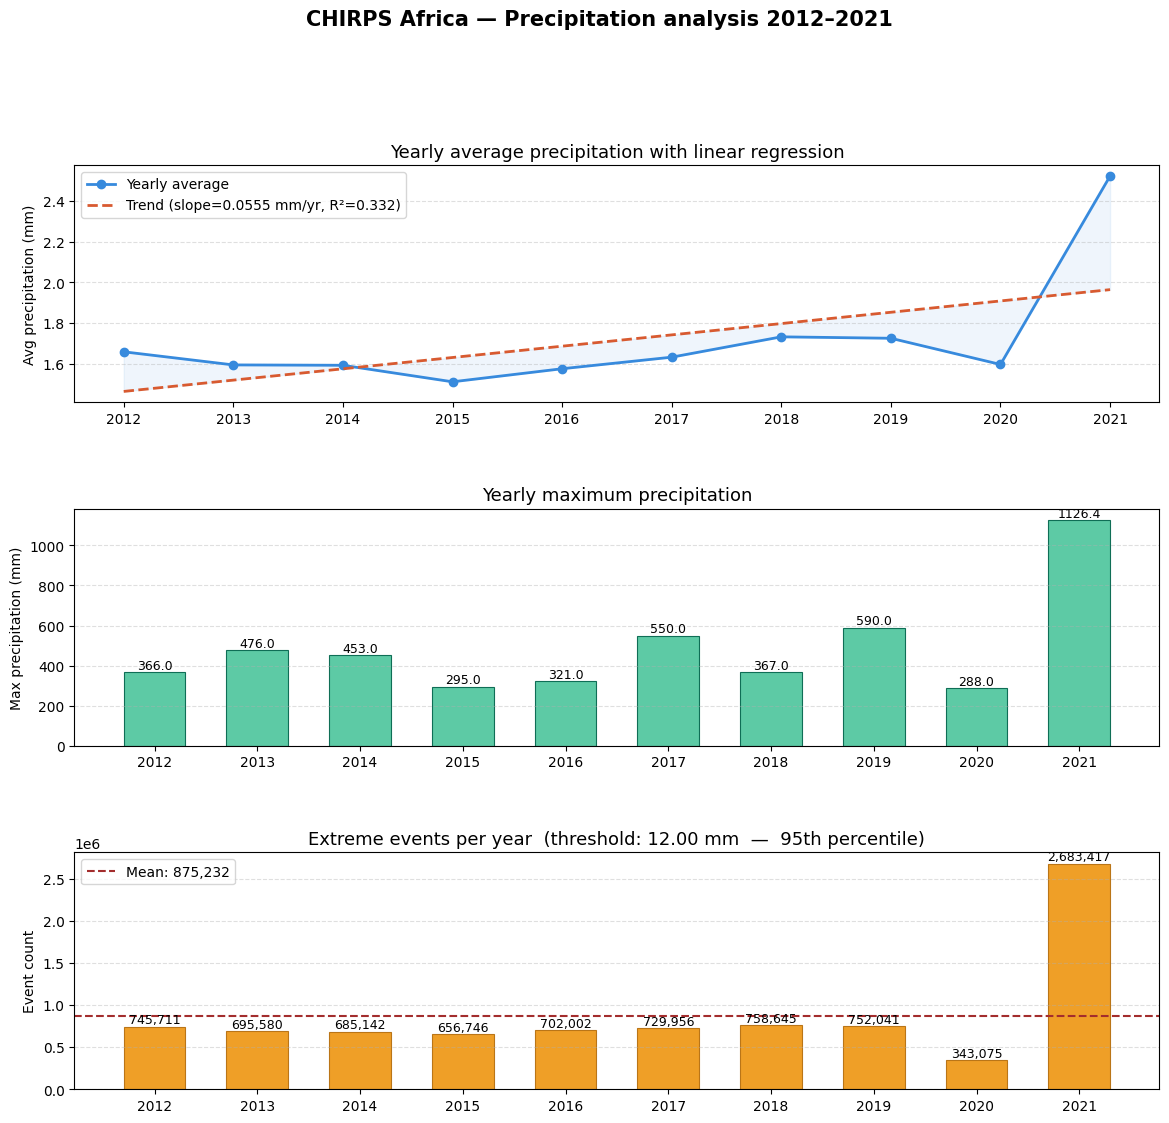

In [19]:
# ── Plot ───────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(14, 12))
gs  = gridspec.GridSpec(3, 1, hspace=0.45)

years = yearly_stats['year'].values

# — Panel 1: Yearly average + regression trend —
ax1 = fig.add_subplot(gs[0])
ax1.plot(years, yearly_stats['avg_pr'], marker='o', color='#378ADD',
         linewidth=2, markersize=6, label='Yearly average')
ax1.plot(years, yearly_stats['trend'], linestyle='--', color='#D85A30',
         linewidth=2, label=f'Trend (slope={slope:.4f} mm/yr, R²={r**2:.3f})')
ax1.fill_between(years, yearly_stats['avg_pr'], yearly_stats['trend'],
                 alpha=0.08, color='#378ADD')
ax1.set_title('Yearly average precipitation with linear regression', fontsize=13)
ax1.set_ylabel('Avg precipitation (mm)')
ax1.set_xticks(years)
ax1.legend(fontsize=10)
ax1.grid(axis='y', linestyle='--', alpha=0.4)

# — Panel 2: Yearly maximum —
ax2 = fig.add_subplot(gs[1])
bars = ax2.bar(years, yearly_stats['max_pr'], color='#5DCAA5',
               edgecolor='#0F6E56', linewidth=0.8, width=0.6)
for bar, val in zip(bars, yearly_stats['max_pr']):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f'{val:.1f}', ha='center', va='bottom', fontsize=9)
ax2.set_title('Yearly maximum precipitation', fontsize=13)
ax2.set_ylabel('Max precipitation (mm)')
ax2.set_xticks(years)
ax2.grid(axis='y', linestyle='--', alpha=0.4)

# — Panel 3: Extreme event counts per year —
ax3 = fig.add_subplot(gs[2])
bars3 = ax3.bar(extreme_per_year['year'], extreme_per_year['extreme_count'],
                color='#EF9F27', edgecolor='#BA7517', linewidth=0.8, width=0.6)
for bar, val in zip(bars3, extreme_per_year['extreme_count']):
    ax3.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 20,
             f'{val:,}', ha='center', va='bottom', fontsize=9)
ax3.axhline(extreme_per_year['extreme_count'].mean(), color='#A32D2D',
            linestyle='--', linewidth=1.5,
            label=f"Mean: {extreme_per_year['extreme_count'].mean():,.0f}")
ax3.set_title(f'Extreme events per year  (threshold: {threshold_95:.2f} mm  —  95th percentile)',
              fontsize=13)
ax3.set_ylabel('Event count')
ax3.set_xticks(extreme_per_year['year'])
ax3.legend(fontsize=10)
ax3.grid(axis='y', linestyle='--', alpha=0.4)

fig.suptitle('CHIRPS Africa — Precipitation analysis 2012–2021',
             fontsize=15, fontweight='bold', y=1.01)

plt.savefig('precipitation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()